# An Exploration Of Musical Characteristics Based On A Spotify Dataset: Their Impact On Popularity

# By Carol Mac Neill and Alejandro Lopez

# DSCI235 Final Project

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(pd.__version__)

3.0.0


Music feels magical because it is interwoven into so many facets of our humanity. In a sense, listening to music seems like a fundamental part of the human experience. But what is it about music that makes us so drawn to it? Although it’s hard to answer that philosophical question with a dataset, more practical questions like ‘how do specific characteristics of music make a song popular?’ are possible to determine. In this project we would like to find answers to interesting questions on modern musical taste. 

For this project we selected a Spotify song and music dataset which is separated into five specific csv files. Each of the files compares music by providing qualitative data that tracks characteristics like artist, genre, name with quantitative characteristic values that track popularity, tempo, danceability, liveliness, acousticness and instrumentalness amongst others. The main dataset has rows of individual songs with a total amount reaching about 170,500. While the other datasets coalesce the songs into categories: data by artist, data by year, data by genres and data with genres. Although 170,000 seems like a tremendous number of songs, the size is actually quite small in comparison to Spotify’s full catalog of songs which by Google estimates reaches about 100 million. As such, it’s possible that the collected data in these datasets is skewed based on its collection methods. From reading the code that was used to generate the list, it’s likely that the data was accumulated by recommended music from each year, or that it’s gathered based on Spotify's recommendations from a user input specifying a specific song to start from. Because of this, our analysis may not be as accurate compared to internal analytics performed by Spotify on their database. But interesting answers may be available to us from it nonetheless.

## Getting the data ready for analysis

In order to ensure that we can answer the questions first we have to ensure the datasets do not have null-values, ASCII control charachters, and data that does not make sense in the context of the columns. First we will load in the data.

In [57]:

spotify_data = pd.read_csv('datasets/spotify_dataset/data.csv')

For a quick review of the dataset structure we can call info() method

In [58]:
spotify_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  str    
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  str    
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  str    
 15  popularity        170653 non-null  int64  
 16  release_date      170653 non-nu

With this info() method we see that the amount of entries are equal to the Non-Null count. So we can infer that the datasets have no null values that have to be removed.

The first questions that we had about this data were about determining the meaning of the mode column and the key column. In order to do that we first checked what values are present in these categories.

In [59]:
spotify_data['mode'].unique()

array([1, 0])

In [60]:
spotify_data['key'].unique()

array([10,  7,  3,  5,  2,  0,  1,  8,  9,  4, 11,  6])

By checking the total uniques values of the mode and key values we found that there were two unique values within mode and 12 values within the key columns. This allows us to then search for the interpretation of these ranges online and determine that the mode relates to a song being in a Major key: 1 or Minor key: 0. Since the key column has 12 values from 0-11 we determined that it is using the Pitch class system. 

![image.png](attachment:image.png)

We also wanted to ensure that there are no songs which have durations of "0" seconds or negative seconds.

In [61]:
(spotify_data['duration_ms'] <= 0).any()

np.False_

We can see that all of the songs are at least of a length greater  0 seconds but we also want to discard songs of length less than 20 seconds.

In [62]:
spotify_data = spotify_data.loc[spotify_data['duration_ms'] > 20000]
spotify_data.info()


<class 'pandas.DataFrame'>
Index: 170602 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170602 non-null  float64
 1   year              170602 non-null  int64  
 2   acousticness      170602 non-null  float64
 3   artists           170602 non-null  str    
 4   danceability      170602 non-null  float64
 5   duration_ms       170602 non-null  int64  
 6   energy            170602 non-null  float64
 7   explicit          170602 non-null  int64  
 8   id                170602 non-null  str    
 9   instrumentalness  170602 non-null  float64
 10  key               170602 non-null  int64  
 11  liveness          170602 non-null  float64
 12  loudness          170602 non-null  float64
 13  mode              170602 non-null  int64  
 14  name              170602 non-null  str    
 15  popularity        170602 non-null  int64  
 16  release_date      170602 non-null  s

We will convert duration_ms to seconds if needed at the time of display

Now we can start to find some answers on how the charachteristics of songs influence popularity within this dataset. 

What charachteristics have the biggest weight impact on a song's popularity?

To figure this out, we can do correlation testing via the Pearson correlational model, and then apply a very simple linear regression model. The charachteristics we will compare are: valence, acousticness, danceability, energy, instrumentalness, liveness, loudness, speechiness and tempo since they have the same underlying data types. But first we need to ensure that these charachteristcs are being represented in the same number range.

In [63]:
characteristics = [
    'valence', 'acousticness', 'danceability', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo'
]

char_ranges = spotify_data[characteristics].agg(['min', 'max'])
print(char_ranges)

     valence  acousticness  danceability  energy  instrumentalness  liveness  \
min      0.0         0.000         0.000     0.0               0.0       0.0   
max      1.0         0.996         0.988     1.0               1.0       1.0   

     loudness  speechiness    tempo  
min   -60.000         0.00    0.000  
max     3.855         0.97  243.507  


We see that loudness and tempo are not on the same scale of 0-1 as the other categories, they are not directly comparable against the others without standarization. So we won't use them in this analysis.


In [64]:
characteristics_to_compare =[
    'valence', 'acousticness', 'danceability', 'energy',
    'instrumentalness', 'liveness', 'speechiness'
]

## Drop unused columns and create separate dataframe

charachteristics_data = spotify_data[characteristics_to_compare + ['popularity']].dropna()

## find Pearson correlation

pearson_correlation = charachteristics_data.corr(method='pearson')['popularity'].sort_values(ascending=False)

print(pearson_correlation)


popularity          1.000000
energy              0.484963
danceability        0.199232
valence             0.013883
liveness           -0.076345
speechiness        -0.171897
instrumentalness   -0.296722
acousticness       -0.573165
Name: popularity, dtype: float64


The above code shows the correlation of each attribute when compared to popularity, where 1 is very high positive correlation and -1 is very high negative correlation. This does not mean causation of the popularity is caused by any of the categories but it does show a sign that the 'energy' attribute may contribute more than others positively, while acousticness may be a more impactful detriment to popularity. In order to find the a more accurate approximation of how each attribute impacts popularity, a multivariate linear regression machine learning model could be trained. But that is outside the scope of this class and it's learnings so we will move forward to other questions. 

An interesting proposition is to check on the same correlation model if we are only looking at the top 1% of popular songs in the dataset. Then review how that correlation's set of charachterisics matches up against the one performed on the full dataset. I will start by finding the top 1% of songs based on popularity.

In [65]:
top_1_percent = spotify_data[spotify_data['popularity'] >= spotify_data['popularity'].quantile(.9)]

print(top_1_percent.info())

<class 'pandas.DataFrame'>
Index: 17552 entries, 2206 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   valence           17552 non-null  float64
 1   year              17552 non-null  int64  
 2   acousticness      17552 non-null  float64
 3   artists           17552 non-null  str    
 4   danceability      17552 non-null  float64
 5   duration_ms       17552 non-null  int64  
 6   energy            17552 non-null  float64
 7   explicit          17552 non-null  int64  
 8   id                17552 non-null  str    
 9   instrumentalness  17552 non-null  float64
 10  key               17552 non-null  int64  
 11  liveness          17552 non-null  float64
 12  loudness          17552 non-null  float64
 13  mode              17552 non-null  int64  
 14  name              17552 non-null  str    
 15  popularity        17552 non-null  int64  
 16  release_date      17552 non-null  str    
 17  speec

In [66]:
top_1_percent.sort_values(by='popularity', ascending=False).head(5)

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
19611,0.145,2020,0.4010,"['Bad Bunny', 'Jhay Cortez']",0.731,205090,0.573,1,47EiUVwUp4C9fGccaPuUCS,0.000052,4,0.1130,-10.059,0,Dakiti,100,2020-10-30,0.0544,109.928
19606,0.756,2020,0.2210,"['24kGoldn', 'iann dior']",0.700,140526,0.722,1,3tjFYV6RSFtuktYl3ZtYcq,0.000000,7,0.2720,-3.558,0,Mood (feat. iann dior),99,2020-07-24,0.0369,90.989
19618,0.737,2020,0.0112,['BTS'],0.746,199054,0.765,0,0t1kP63rueHleOhQkYSXFY,0.000000,6,0.0936,-4.410,0,Dynamite,97,2020-08-28,0.0993,114.044
19608,0.357,2020,0.0194,"['Cardi B', 'Megan Thee Stallion']",0.935,187541,0.454,1,4Oun2ylbjFKMPTiaSbbCih,0.000000,1,0.0824,-7.509,1,WAP (feat. Megan Thee Stallion),96,2020-08-07,0.3750,133.073
19610,0.682,2020,0.4680,['Ariana Grande'],0.737,172325,0.802,1,35mvY5S1H3J2QZyna3TFe0,0.000000,0,0.0931,-4.771,1,positions,96,2020-10-30,0.0878,144.015


On a side note, unsurprisingly we find artists Bad Bunny, BTS, Cardi B and Ariana Grande are artists in the top 5 songs. I personally would say all of these songs are high on energy and danceability which coincides with the Pearson models findings when run on all the data.

But interestingly the top 5 songs are from 2020.

For now we can check the Pearson model on this set of popular songs.

In [67]:
## Drop unused columns and create separate dataframe

charachteristics_data_for_top_1 = top_1_percent[characteristics_to_compare + ['popularity']].dropna()

## find Pearson correlation

pearson_correlation_for_top_1 = charachteristics_data_for_top_1.corr(method='pearson')['popularity'].sort_values(ascending=False)

print(pearson_correlation_for_top_1)

popularity          1.000000
danceability        0.131280
speechiness         0.047983
energy              0.026455
valence            -0.004741
liveness           -0.028691
acousticness       -0.055311
instrumentalness   -0.106775
Name: popularity, dtype: float64


Let's create a plot to compare the data from the pearson_correlation on all data vs the top 1%. First we will want to drop popularity from the categories.

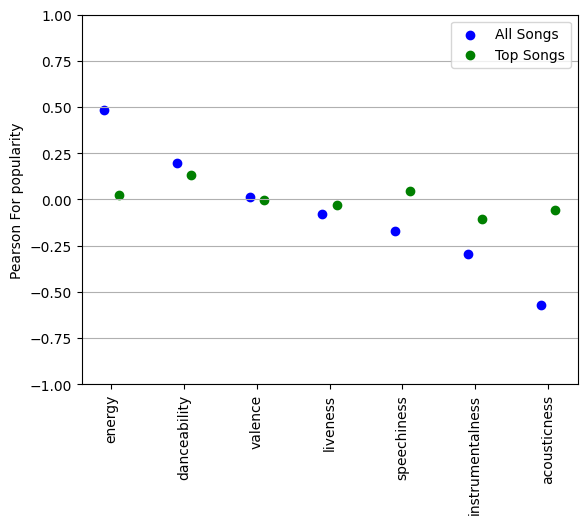

In [ ]:
top_songs = pearson_correlation_for_top_1.drop(labels='popularity')
all_songs = pearson_correlation.drop(labels='popularity')
names = all_songs.index
x_axis = np.arange(len(names))

## To differentiate the two datasets, we can add and remove .1 from the first parameter on the plt.scatter function so that they are slightly apart and won't overlap in cases where the same value appears between both for a particular category.

plt.scatter(x_axis - 0.1, all_songs.loc[names], color='blue', label='All Songs')
plt.scatter(x_axis + 0.1, top_songs.loc[names], color='green', label='Top Songs')

plt.xticks(x_axis, names, rotation='vertical')

plt.ylim(-1, 1)
plt.ylabel('Pearson For popularity')
plt.legend()
plt.grid(True, axis='y')
plt.show()


Immediately after seeing the Pearson results between all the data and the top 1% of songs I wanted to graph it because it shows an interesting relationship. The Pearson correlation for the top songs shows all of the categories remaining near 0, insinuating little impact. My intuition to why this was happening was that the dataset of the top 1 percent of songs is too small in quantity, and therefore the correlational results between the categories seem unimpactful. This matched up with my previous learnings on the Pearson model being less reliable on small datasets because it the correlation coefficients are likely to shrink to zero if there is a weak linear assosiation in the data. 

Okay, let's move forward to another question! How have charachteristics of songs changed over time? 

A simple way to check is to sort the songs into decades starting from the beginning of the dataset to today, then to plot the charachteristics individully through bar graphs and see how they change throughout time. 

I'd like to do a groupby based on year, but that will only group the songs by individual year on it's own, so a aggregation function may be nessesary.

In [ ]:
# The assign function allows for building a function that will collapse all years into the decade preceding them, for example 1966 will be integer floor divided by 10 which equals 196, and then multiplied by 10 to get the correct decade.

spotify_with_decade = spotify_data.assign(
    decade=(spotify_data['year'] // 10) * 10
)

# now that I added a decade column, grouping by that column and finding the average charachterisics is possible

songs_by_decade = spotify_with_decade.groupby('decade').agg('mean', numeric_only=True)
songs_by_decade = songs_by_decade.drop(columns='year')

songs_per_decade = spotify_with_decade.groupby('decade').agg(
    number_of_songs=('name', 'count'),
)

print("Before plotting the charachteristics let's see how many songs per decade are in this dataset")
print(songs_per_decade)

Before plotting the charachteristics let's see how many songs per dacade are in this dataset
        number_of_songs
decade                 
1920               5126
1930               9538
1940              15356
1950              19833
1960              19549
1970              19999
1980              19850
1990              19901
2000              19646
2010              19774
2020               2030


Of course I first have to check on how the explicit charachteristic has risen in prominense in music through the ages!

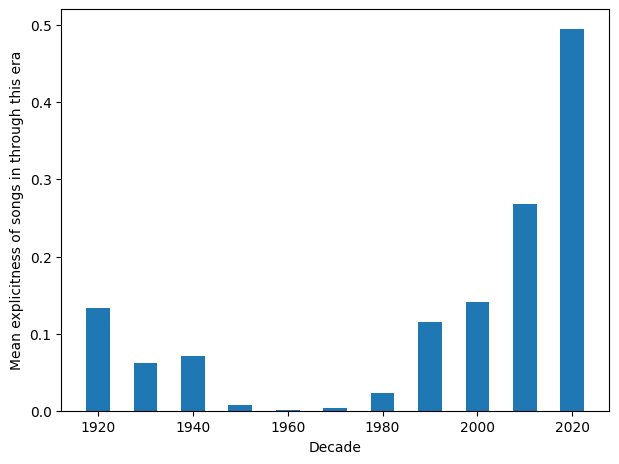

In [ ]:
x_axis = songs_by_decade.index
y_axis = songs_by_decade['explicit']
plt.xlabel("Decade")
plt.ylabel("Mean Explicitness of Songs")

plt.tight_layout()
plt.bar(x=x_axis, height=y_axis, width=5)
plt.show()


As expected, explicit songs have become more dominant in recent decades. An interesting note is that a x^2 relationship seems to be applicable here, it would be interesting to see if this relationship extends before 1920, but the data is not available.

Next let's see how the remaining charachteristics measure up compared to the decades.

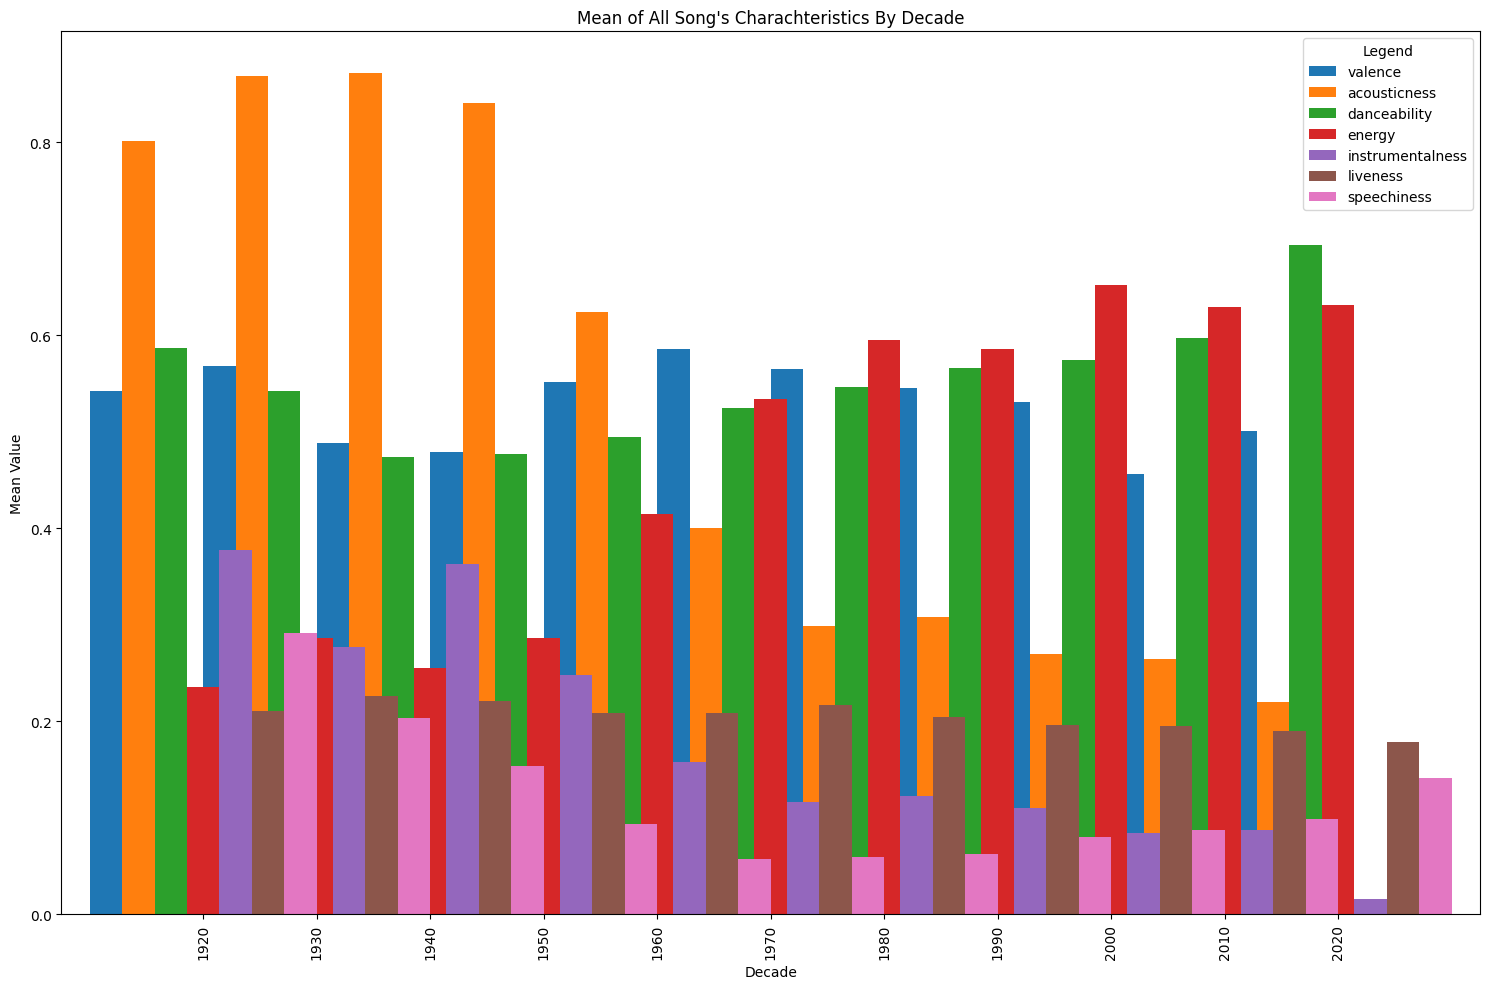

In [99]:
all_charachs_plot = songs_by_decade[characteristics_to_compare]

by_decade_bar_graph = all_charachs_plot.plot(
  kind = 'bar',
  figsize=(15, 10),
  width=2
)

by_decade_bar_graph.set_title("Mean of All Song's Charachteristics By Decade")
by_decade_bar_graph.set_xlabel('Decade')
by_decade_bar_graph.set_ylabel('Mean Value')
by_decade_bar_graph.legend(title='Legend')

plt.tight_layout()
plt.show()


Here we see a reinforcement of previous findings through a different lens. Energy holds strong in a high mean value throughout the ages, while Dancability rises more and more in prominence. Acousticness really has fallen off strongly and my speculation is that the rise of electronic tools like synthezisers, amps and DJ decks contributed to this strongly. 